# MISR DHR Natural-Color RGB — Harmony Compositor Demo

This notebook demonstrates the **MISR L3 DHR natural-color RGB workflow through Harmony** using the locally deployed **Harmony Compositor service**.

For the MISR variable:

`/Land_Parameter_Average/DHR`

the source granule contains four spectral bands:

- `blue_446nm`
- `green_558nm`
- `red_672nm`
- `nir_867nm`

The Compositor selects the configured **red, green, and blue** bands, stacks them in RGB order, and creates a display-ready 3-band DHR variable while preserving the surrounding MISR NetCDF structure.

### Demo flow

**Harmony request → Compositor → composited NetCDF → local RGB visualization**

> This notebook intentionally stops after the Compositor output. Net2Cog and HyBIG are the next integration steps and are not part of this demo.


## Requirements

Install the packages used in this notebook:

```bash
pip install harmony-py xarray netCDF4 numpy matplotlib
```

For Harmony authentication, make sure your Earthdata credentials/token are configured for the environment you are using.


## 1. Set up the output directory and imports


In [4]:
from pathlib import Path
import os

from harmony import Client, Collection, Environment, Request

output_dir = Path("./LOCAL-MISR-COMPOSITOR-output")
output_dir.mkdir(exist_ok=True)

print("Output directory:", output_dir.resolve())


Output directory: /Users/srizvi/Documents/harmony-filtering-demo/LOCAL-MISR-COMPOSITOR-output


## 2. Initialize the Harmony client

This demo is configured for a **local Harmony environment**.  
Make sure your local Harmony deployment is running before submitting the request.

If needed, update `harmony_host_url` for SIT, UAT, or production.


In [6]:
harmony_host_url = "http://localhost:3000"

host_environment = {
    "http://localhost:3000": Environment.LOCAL,
    "https://harmony.sit.earthdata.nasa.gov": Environment.SIT,
    "https://harmony.uat.earthdata.nasa.gov": Environment.UAT,
    "https://harmony.earthdata.nasa.gov": Environment.PROD,
}

environment = host_environment[harmony_host_url]
client = Client(env=environment)

print("Harmony host:", harmony_host_url)
print("Environment :", environment)
print("EDL_TOKEN present:", bool(os.environ.get("EDL_TOKEN")))


Harmony host: http://localhost:3000
Environment : Environment.LOCAL
EDL_TOKEN present: False


## 3. Define the MISR collection, granule, and DHR variable

This request targets the MISR L3 granule used for local Compositor validation.

The requested variable is:

`/Land_Parameter_Average/DHR`


In [8]:
collection = Collection(id="C1262098108-LARC_CLOUD")

granule_id = "G1273228377-LARC_CLOUD"
# MISR_AM1_CGLS_SEP_2022_F06_0032.nc

request = Request(
    collection=collection,
    granule_id=[granule_id],
    variables="/Land_Parameter_Average/DHR",
)

print("Collection :", collection.id)
print("Granule    :", granule_id)
print("Variable   : /Land_Parameter_Average/DHR")
print("Valid request:", request.is_valid())


Collection : C1262098108-LARC_CLOUD
Granule    : G1273228377-LARC_CLOUD
Variable   : /Land_Parameter_Average/DHR
Valid request: True


## 4. Submit the Harmony request

Harmony routes the request to the configured Compositor service.  
The Compositor retrieves its external configuration, processes the DHR variable, and returns the composited NetCDF result.


In [10]:
job_id = client.submit(request)

print("Harmony job ID:", job_id)

client.wait_for_processing(
    job_id,
    show_progress=True
)


 [ Processing:   0% ] |                                                   | [/]

Harmony job ID: c7168d12-addd-41c3-ab2a-b83531e5db51


 [ Processing: 100% ] |###################################################| [|]


## 5. Download the Harmony output

The completed output is downloaded locally so that the DHR RGB structure and image can be inspected directly.


In [12]:
downloaded_files = [
    Path(f.result())
    for f in client.download_all(
        job_id,
        directory=output_dir
    )
]

print("Downloaded files:")
for path in downloaded_files:
    print(" -", path)


LOCAL-MISR-COMPOSITOR-output/38_MISR_AM1_CGLS_SEP_2022_F06_0032_composited.nc
Downloaded files:
 - LOCAL-MISR-COMPOSITOR-output/38_MISR_AM1_CGLS_SEP_2022_F06_0032_composited.nc


# Visualize the Compositor RGB Output

The following cells inspect the downloaded Compositor NetCDF and render:

`/Land_Parameter_Average/DHR`

as a natural-color RGB image.

The expected output structure is:

`DHR(Latitude, Longitude, rgb_band)`

with `rgb_band = 3` in **Red, Green, Blue** order.


## 6. Locate the composited NetCDF output


In [15]:
# Prefer a downloaded NetCDF result.
nc_files = [Path(p) for p in downloaded_files if str(p).lower().endswith(".nc")]

if not nc_files:
    # Fallback: inspect the output directory in case download_all returned
    # a different path representation.
    nc_files = sorted(output_dir.glob("*.nc"))

if not nc_files:
    raise FileNotFoundError(
        f"No NetCDF output was found in {output_dir.resolve()}"
    )

# For this single-granule demo, use the first NetCDF result.
composited_file = nc_files[0]

print("Composited NetCDF:", composited_file.resolve())


Composited NetCDF: /Users/srizvi/Documents/harmony-filtering-demo/LOCAL-MISR-COMPOSITOR-output/38_MISR_AM1_CGLS_SEP_2022_F06_0032_composited.nc


## 7. Inspect the DHR output structure and Compositor metadata


In [17]:
import numpy as np
import xarray as xr

GROUP = "Land_Parameter_Average"
VARIABLE = "DHR"

ds = xr.open_dataset(
    composited_file,
    group=GROUP,
    engine="netcdf4",
    mask_and_scale=True,
)

dhr = ds[VARIABLE]

print("Variable :", f"/{GROUP}/{VARIABLE}")
print("Dimensions:", dhr.dims)
print("Shape     :", dhr.shape)
print("Data type :", dhr.dtype)

if "rgb_band" in ds.variables:
    print("rgb_band values:", ds["rgb_band"].values)

print("\nCompositor metadata:")
for attr in [
    "compositor_channel_order",
    "compositor_source_band_values",
    "compositor_display_range",
]:
    print(f"  {attr}: {dhr.attrs.get(attr, '<not present>')}")

values = np.asarray(dhr.values)
valid = values[np.isfinite(values)]

if valid.size:
    print(f"\nValid data range: {valid.min():.3f} to {valid.max():.3f}")


Variable : /Land_Parameter_Average/DHR
Dimensions: ('Latitude', 'Longitude', 'rgb_band')
Shape     : (360, 720, 3)
Data type : float32
rgb_band values: [1 2 3]

Compositor metadata:
  compositor_channel_order: red,green,blue
  compositor_source_band_values: red_672nm,green_558nm,blue_446nm
  compositor_display_range: 0.0,255.0

Valid data range: 0.000 to 255.000


## 8. Prepare the RGB array

The Compositor output is expected to contain three channels ordered as:

**Red → Green → Blue**

with display values in the range **0–255**.


In [19]:
expected_dims = ("Latitude", "Longitude", "rgb_band")

if not all(dim in dhr.dims for dim in expected_dims):
    raise ValueError(
        "Unexpected DHR dimensions. "
        f"Expected dimensions containing {expected_dims}, found {dhr.dims}"
    )

rgb_data = dhr.transpose(*expected_dims).values

if rgb_data.shape[-1] != 3:
    raise ValueError(
        f"Expected 3 RGB channels, found shape {rgb_data.shape}"
    )

# xarray converts the NetCDF fill value to NaN when mask_and_scale=True.
# Use black for missing pixels in this simple visualization.
rgb = np.nan_to_num(
    rgb_data,
    nan=0.0,
    posinf=255.0,
    neginf=0.0,
)

rgb = np.clip(rgb, 0.0, 255.0).astype(np.uint8)

print("RGB array shape:", rgb.shape)
print("RGB data type  :", rgb.dtype)
print("Display range  :", rgb.min(), "to", rgb.max())


RGB array shape: (360, 720, 3)
RGB data type  : uint8
Display range  : 0 to 255


## 9. Display the MISR DHR natural-color RGB composite


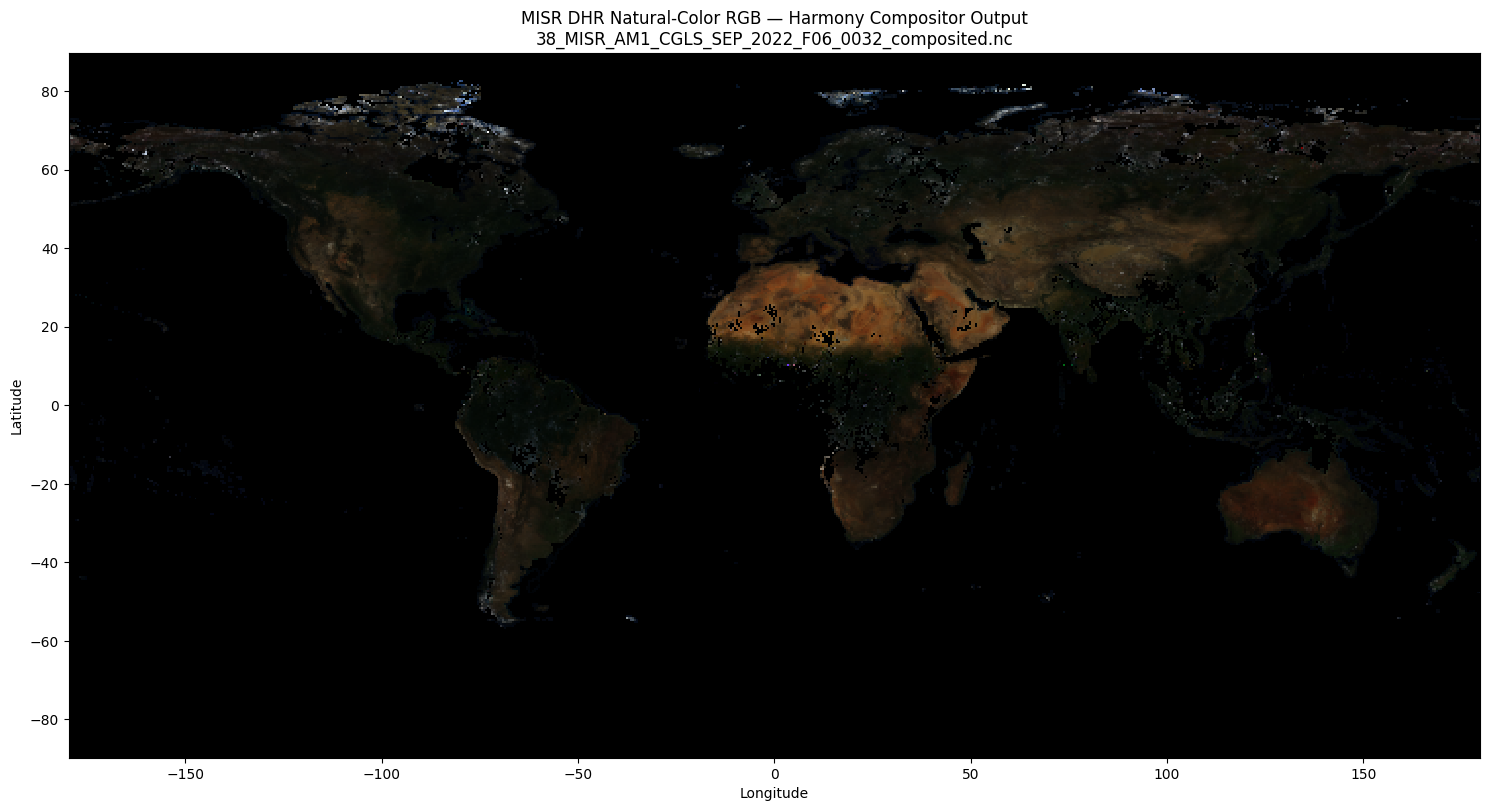

In [21]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15, 8))

lat = ds.coords.get("Latitude")
lon = ds.coords.get("Longitude")

imshow_kwargs = {
    "interpolation": "nearest"
}

# Add geographic axes when 1-D Latitude/Longitude coordinates are available.
if (
    lat is not None
    and lon is not None
    and lat.ndim == 1
    and lon.ndim == 1
):
    imshow_kwargs["extent"] = [
        float(lon.min()),
        float(lon.max()),
        float(lat.min()),
        float(lat.max()),
    ]
    imshow_kwargs["origin"] = (
        "upper"
        if float(lat.values[0]) > float(lat.values[-1])
        else "lower"
    )
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
else:
    ax.set_xlabel("Longitude pixel")
    ax.set_ylabel("Latitude pixel")

ax.imshow(rgb, **imshow_kwargs)

ax.set_title(
    "MISR DHR Natural-Color RGB — Harmony Compositor Output\n"
    + composited_file.name
)

plt.tight_layout()
plt.show()


## 10. Optional validation view — individual RGB channels

This view is useful for confirming that the three output channels are present in the expected **Red, Green, Blue** order.


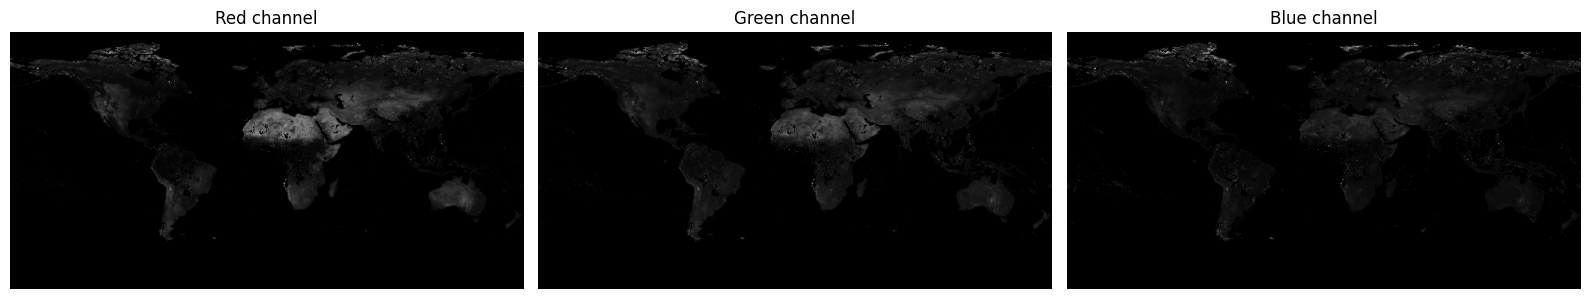

In [23]:
channel_names = ["Red", "Green", "Blue"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for index, (ax, channel_name) in enumerate(zip(axes, channel_names)):
    ax.imshow(
        rgb[:, :, index],
        cmap="gray",
        vmin=0,
        vmax=255
    )
    ax.set_title(f"{channel_name} channel")
    ax.axis("off")

plt.tight_layout()
plt.show()


## Demo result

A successful run should confirm that:

- Harmony successfully processes the requested MISR granule through the Compositor.
- `/Land_Parameter_Average/DHR` is returned as a 3-channel variable.
- The DHR dimensions are `(Latitude, Longitude, rgb_band)`.
- The three channels represent **Red, Green, Blue**.
- The output can be rendered directly as a MISR natural-color RGB image.

### Next step

Pass this composited NetCDF output to **Net2Cog** and verify that the 3-D DHR variable is converted into a valid **3-band RGB GeoTIFF**. The resulting GeoTIFF can then be tested with **HyBIG**.


## 11. Enhanced display views for visualization only

The Compositor output shown above is the direct RGB mapping from the composited DHR values.
Because many MISR reflectance values are concentrated at the low end of the `0–255` display range,
the image can appear dark.

The following views apply **display-only enhancement** so the output is easier to see in the notebook.
These cells **do not change the Compositor output file**. They only create brighter display renderings.


### 11a. Brightness-enhanced RGB view

This first view applies a simple multiplicative brightness stretch.
It is useful for a quick visual check.


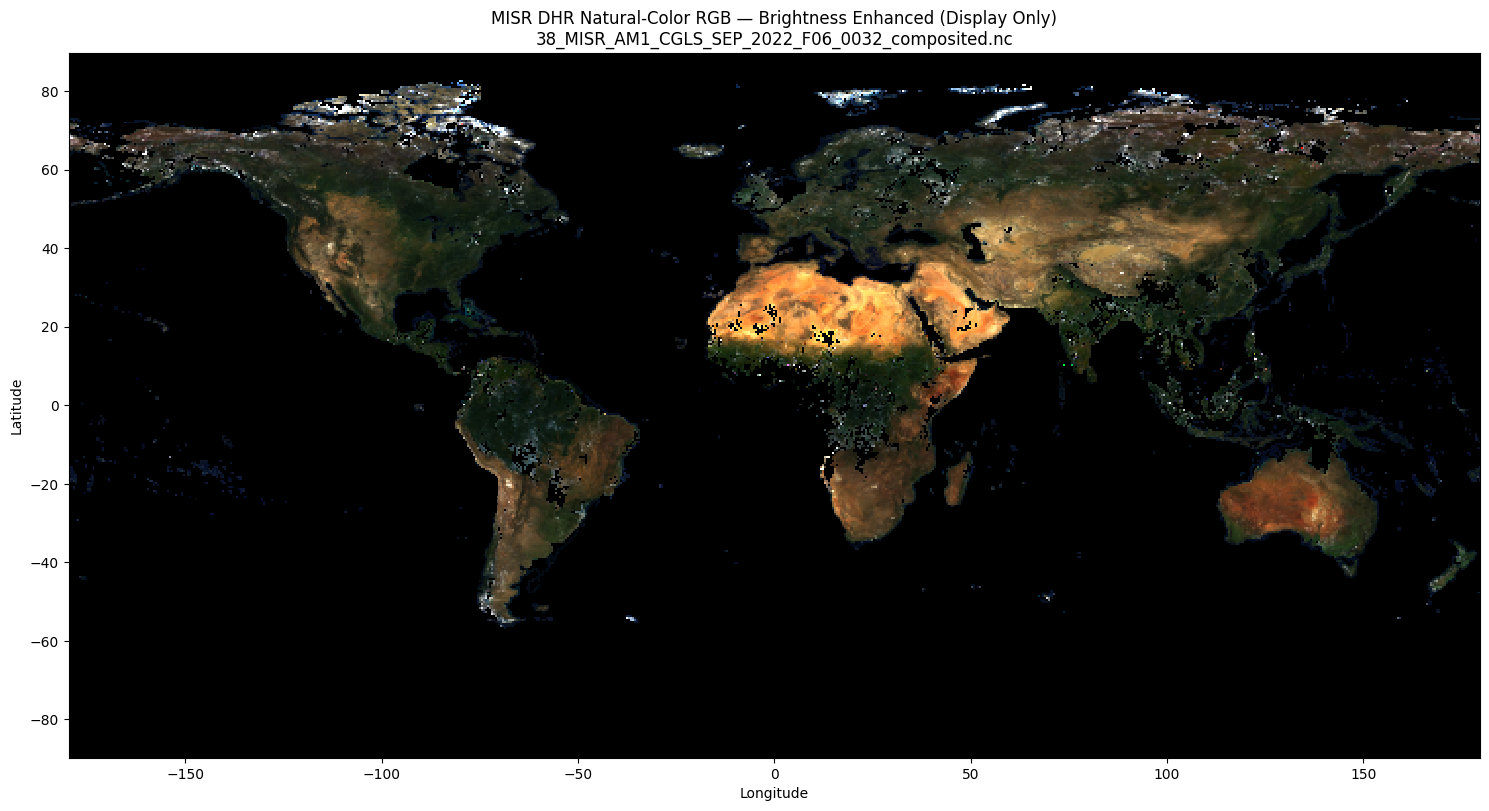

In [27]:
rgb_bright = np.clip(rgb.astype(np.float32) * 2.5, 0, 255).astype(np.uint8)

fig, ax = plt.subplots(figsize=(15, 8))

lat = ds.coords.get("Latitude")
lon = ds.coords.get("Longitude")

imshow_kwargs = {
    "interpolation": "nearest"
}

if (
    lat is not None
    and lon is not None
    and lat.ndim == 1
    and lon.ndim == 1
):
    imshow_kwargs["extent"] = [
        float(lon.min()),
        float(lon.max()),
        float(lat.min()),
        float(lat.max()),
    ]
    imshow_kwargs["origin"] = (
        "upper"
        if float(lat.values[0]) > float(lat.values[-1])
        else "lower"
    )
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
else:
    ax.set_xlabel("Longitude pixel")
    ax.set_ylabel("Latitude pixel")

ax.imshow(rgb_bright, **imshow_kwargs)
ax.set_title(
    "MISR DHR Natural-Color RGB — Brightness Enhanced (Display Only)\n"
    + composited_file.name
)

plt.tight_layout()
plt.show()


### 11b. Percentile-stretched RGB view

This view is usually better than a simple brightness multiplier.  
Each channel is stretched independently using the **2nd to 98th percentile**
of valid nonzero pixels, then rescaled to `0–255` for display.

This improves contrast while preserving the existing Compositor output file.


Per-channel percentile stretch used:
  Red: low=2.000, high=107.000
  Green: low=5.000, high=74.000
  Blue: low=5.000, high=54.000


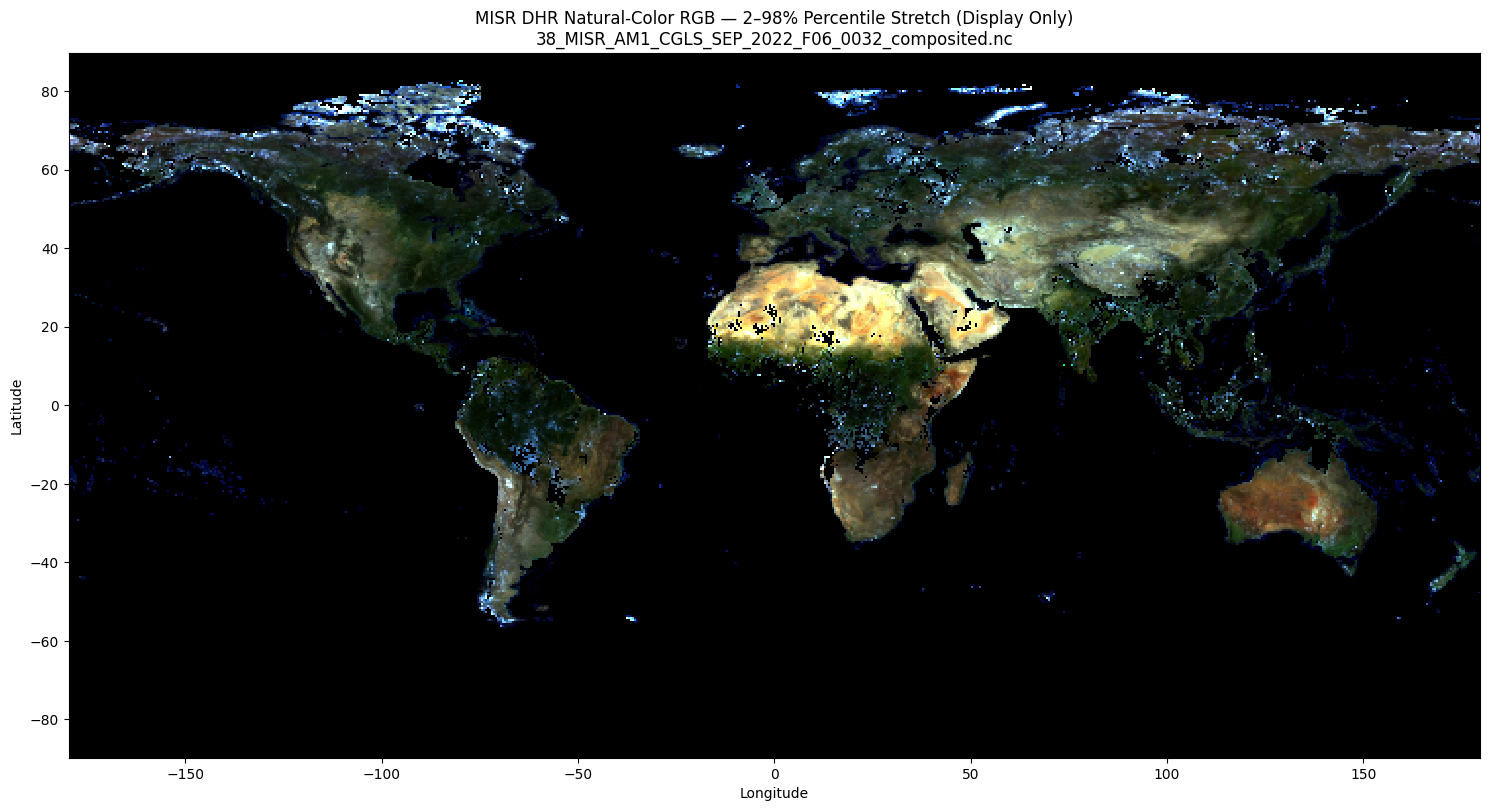

In [29]:
rgb_stretched = rgb.astype(np.float32).copy()

stretch_info = []

for i, channel_name in enumerate(["Red", "Green", "Blue"]):
    channel = rgb_stretched[:, :, i]
    valid = channel[channel > 0]

    if valid.size == 0:
        low, high = 0.0, 255.0
    else:
        low = float(np.percentile(valid, 2))
        high = float(np.percentile(valid, 98))
        if high <= low:
            high = low + 1.0

    stretch_info.append((channel_name, low, high))

    channel = (channel - low) / (high - low) * 255.0
    rgb_stretched[:, :, i] = np.clip(channel, 0, 255)

rgb_stretched = rgb_stretched.astype(np.uint8)

print("Per-channel percentile stretch used:")
for channel_name, low, high in stretch_info:
    print(f"  {channel_name}: low={low:.3f}, high={high:.3f}")

fig, ax = plt.subplots(figsize=(15, 8))

lat = ds.coords.get("Latitude")
lon = ds.coords.get("Longitude")

imshow_kwargs = {
    "interpolation": "nearest"
}

if (
    lat is not None
    and lon is not None
    and lat.ndim == 1
    and lon.ndim == 1
):
    imshow_kwargs["extent"] = [
        float(lon.min()),
        float(lon.max()),
        float(lat.min()),
        float(lat.max()),
    ]
    imshow_kwargs["origin"] = (
        "upper"
        if float(lat.values[0]) > float(lat.values[-1])
        else "lower"
    )
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
else:
    ax.set_xlabel("Longitude pixel")
    ax.set_ylabel("Latitude pixel")

ax.imshow(rgb_stretched, **imshow_kwargs)
ax.set_title(
    "MISR DHR Natural-Color RGB — 2–98% Percentile Stretch (Display Only)\n"
    + composited_file.name
)

plt.tight_layout()
plt.show()


### 11c. Side-by-side comparison

This comparison helps show the difference between:

- the **direct Compositor RGB output**
- the **brightness-enhanced** view
- the **percentile-stretched** view

Again, only the display is changed here — not the underlying NetCDF output.


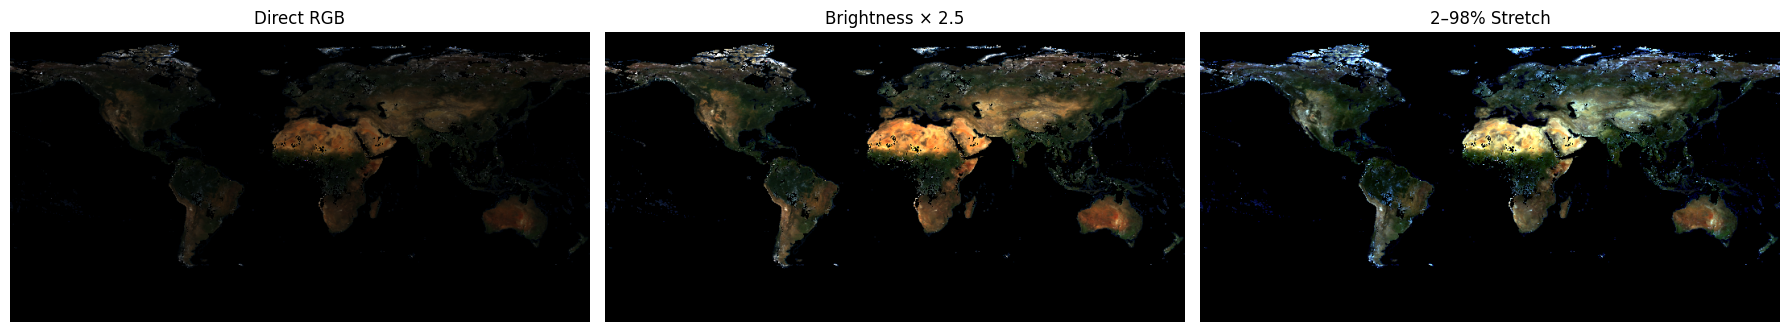

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

comparison_images = [
    ("Direct RGB", rgb),
    ("Brightness × 2.5", rgb_bright),
    ("2–98% Stretch", rgb_stretched),
]

for ax, (title, image) in zip(axes, comparison_images):
    ax.imshow(image)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()


### Note

For science processing and downstream service integration, the Compositor output should remain unchanged.
These final notebook cells are only for **human-friendly display and review**.
